# IHMM Demonstration Notebook

This notebook demonstrates how to use the IHMM implementation for fixation detection, including:
- Generating synthetic data
- Running the IHMM pipeline
- Visualizing results


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# import your functions
from pymovements.events.detection.ihmm import ihmm, compute_hmm

import pymovements as pm
from pymovements.gaze.experiment import Experiment
import polars as pl

%config InlineBackend.figure_format = 'svg'

## Load Toy Dataset

In [2]:
# Define the experimental setup
experiment = Experiment(
    screen_width_px=1280,
    screen_height_px=1024,
    screen_width_cm=38,
    screen_height_cm=30.2,
    distance_cm=68,
    origin="upper left",
    sampling_rate=250.0,
)

# Load gaze data from a CSV file and initialize three Gaze objects to test different modes.
gaze1 = pm.gaze.from_csv(
    "./gaze-toy-example.csv",
    experiment=experiment,
    time_column="time",
    pixel_columns=["x", "y"],
)

gaze2 = pm.gaze.from_csv(
    "./gaze-toy-example.csv",
    experiment=experiment,
    time_column="time",
    pixel_columns=["x", "y"],
)
gaze3 = pm.gaze.from_csv(
    "./gaze-toy-example.csv",
    experiment=experiment,
    time_column="time",
    pixel_columns=["x", "y"],
)

# Convert pixel coordinates to degrees of visual angle (dva).
# Requires a valid Experiment with screen geometry and distance.
gaze1.pix2deg()
gaze1.pos2vel()

gaze2.pix2deg()
gaze2.pos2vel()

gaze3.pix2deg()
gaze3.pos2vel()

gaze1

time,pixel,position,velocity
i64,list[f64],list[f64],list[f64]
0,"[206.8, 152.4]","[-10.697598, -8.852399]","[null, null]"
4,"[207.0, 151.5]","[-10.692768, -8.874233]","[null, null]"
8,"[207.6, 151.9]","[-10.678275, -8.86453]","[1.610284, -0.101097]"
12,"[207.6, 152.2]","[-10.678275, -8.857252]","[1.107104, -0.909672]"
16,"[207.8, 151.6]","[-10.673444, -8.871807]","[0.6039, -1.617239]"
…,…,…,…
17204,"[349.3, 420.0]","[-7.220662, -2.272553]","[29.879682, -16.852411]"
17208,"[362.7, 418.1]","[-6.89053, -2.319691]","[43.841686, -7.339814]"
17212,"[371.2, 419.0]","[-6.680877, -2.297363]","[9.957777, -7.442396]"


# The function parameters are as such
```
def ihmm(
        positions: list[list[float]] | list[tuple[float, float]] | np.ndarray,
        timesteps: list[int] | np.ndarray | None = None,
        mu: list[float] | np.ndarray | None = None,
        sigma: list[float] | np.ndarray | None = None,
        init_state: list[float] | np.ndarray | None = None,
        transition_probabilities: list[list[float]] | np.ndarray | None = None,
        reestimation_max_iters: int = 100,
        initialization: str | None = None,
        verbose: bool = False,
        name: str = 'fixation',
) -> Events:
```

## Run IHMM with default parameters

In [3]:
dict = {'mu': [2.0140785987072225, 69.41529375180251], 'sigma': [1.3220152347857494, 87.32409626093246], 'init': [1.e+00, 1.e-12], 'trans': [[0.97360507, 0.02639493],
       [0.07593547, 0.92406453]]}

gaze1.detect("ihmm",name="fixation_ihmm",hmm_parameters_dict = dict)

gaze1.events


name,onset,offset,duration
str,i64,i64,i64
"""fixation_ihmm""",0,41,41
"""fixation_ihmm""",51,97,46
"""fixation_ihmm""",112,144,32
"""fixation_ihmm""",161,213,52
"""fixation_ihmm""",231,253,22
…,…,…,…
"""fixation_ihmm""",4171,4179,8
"""fixation_ihmm""",4197,4207,10
"""fixation_ihmm""",4212,4216,4


# Run IHMM with reestimation

In [10]:
# Use the "initialization" parameter to specify run the Baum-Welch algorithm to obtain optimal starting parameters

# Flag "verbose" as True to print and see the optimal obtained parameters

# The parameter "reestimation_max_iters" is used to stop the Baum-Welch algorithm if it runs too long,

# it should be need only for very large datasets as the algorithm usually reached convergence quickly 

dict = {'mu': [np.float64(2.0140785987072225), np.float64(69.41529375180251)], 'sigma': [np.float64(1.3220152347857494), np.float64(87.32409626093246)], 'init': np.array([1.e+00, 1.e-12]), 'trans': np.array([[0.97360507, 0.02639493],
       [0.07593547, 0.92406453]])}

gaze2.detect("ihmm", reestimation = True, hmm_parameters_dict = dict, verbose = True, reestimation_max_iters = 100, name="fixation_ihmm")

gaze2.events

{'mu': array([ 2.01404035, 69.41355479]), 'sigma': array([ 1.32196072, 87.32352934]), 'init': array([  0.        , -27.63102112]), 'trans': array([[-0.02675077, -3.63453752],
       [-2.5778625 , -0.0789741 ]])}
Optimal parameters found by reestimation are:
{'mu': [2.014040353358042, 69.41355478517373], 'sigma': [1.3219607172984098, 87.32352933792987], 'init': array([1.e+00, 1.e-12]), 'trans': array([[0.97360386, 0.02639614],
       [0.07593614, 0.92406386]])}
{'mu': array([ 2.01404035, 69.41355479]), 'sigma': array([ 1.32196072, 87.32352934]), 'init': array([  0.        , -27.63102112]), 'trans': array([[-0.02675077, -3.63453752],
       [-2.5778625 , -0.0789741 ]])}


name,onset,offset,duration,location
str,i64,i64,i64,list[f64]
"""fixation_ihmm""",0,41,41,"[207.6, 151.645455]"
"""fixation_ihmm""",51,97,46,"[207.733333, 150.425]"
"""fixation_ihmm""",112,144,32,"[207.1, 152.066667]"
"""fixation_ihmm""",161,213,52,"[182.115385, 151.169231]"
"""fixation_ihmm""",231,253,22,"[166.1, 148.533333]"
…,…,…,…,…
"""fixation_ihmm""",4171,4179,8,null
"""fixation_ihmm""",4197,4207,10,null
"""fixation_ihmm""",4212,4216,4,null


In [5]:
# 

mu= [10, 300]

sigma= [11, 386]

init= [0.5, 0.5] 

trans= [[0.95, 0.05], [0.05, 0.95]] 
    

gaze3.detect("ihmm", mu=mu, sigma=sigma, init_state = init, transition_probabilities = trans, name="fixation_ihmm")

gaze3.events

name,onset,offset,duration
str,i64,i64,i64
"""fixation_ihmm""",0,42,42
"""fixation_ihmm""",46,98,52
"""fixation_ihmm""",104,145,41
"""fixation_ihmm""",152,214,62
"""fixation_ihmm""",220,254,34
…,…,…,…
"""fixation_ihmm""",4058,4133,75
"""fixation_ihmm""",4138,4181,43
"""fixation_ihmm""",4188,4239,51


## Visualize Detected events

(<Figure size 1500x500 with 1 Axes>, <Axes: >)

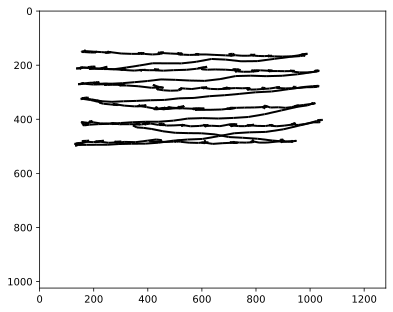

In [6]:
# visualize the data
pm.plotting.traceplot(gaze1)

(<Figure size 1500x500 with 1 Axes>, <Axes: >)

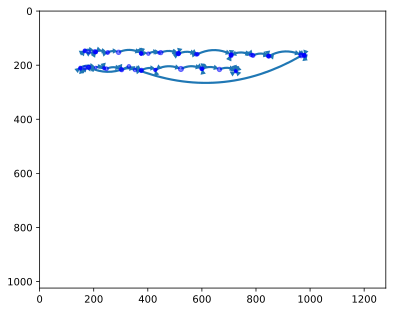

In [7]:
gaze1.compute_event_properties(("location", {"position_column": "pixel"}))

pm.plotting.scanpathplot(gaze1, event_name="fixation_ihmm")

(<Figure size 1500x500 with 1 Axes>, <Axes: >)

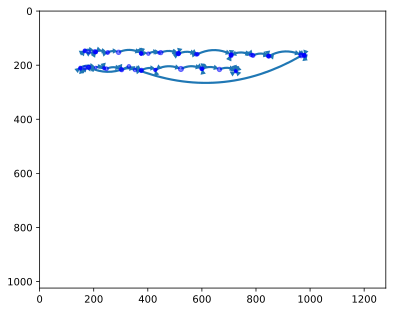

In [8]:
gaze2.compute_event_properties(("location", {"position_column": "pixel"}))

pm.plotting.scanpathplot(gaze2, event_name="fixation_ihmm")

(<Figure size 1500x500 with 1 Axes>, <Axes: >)

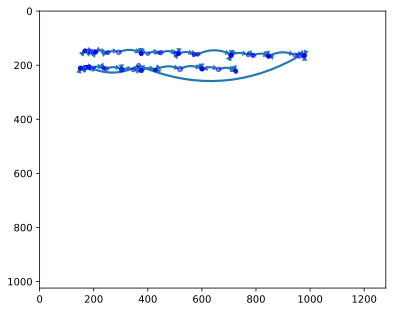

In [9]:
gaze3.compute_event_properties(("location", {"position_column": "pixel"}))

pm.plotting.scanpathplot(gaze3, event_name="fixation_ihmm")